In [69]:
import matplotlib
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from src.OrganoidMesh import OrganoidMesh
from src.mesh_analysis import *
from src.nonlocal_correlations import *
from src.cell_graph_functions import *

In [70]:
def hks_to_curv_proxy_Y(HKS, t_values, d=2, clip_percentiles=None):
    """
    HKS: (N, T) array, per-cell heat kernel signatures.
    t_values: (T,) small positive times actually used for HKS.
    Returns: Y (N, T) where Y[:,j] ≈ G(x) (up to higher-order terms).
    Optionally clips tails per t if clip_percentiles=(low, high).
    """
    HKS = np.asarray(HKS, dtype=np.float64)
    t_values = np.asarray(t_values, dtype=np.float64)
    assert HKS.ndim == 2 and t_values.ndim == 1 and HKS.shape[1] == t_values.shape[0]
    four_pi_t_pow = (4.0 * np.pi * t_values) ** (d/2.0)   # shape (T,)
    Y = (HKS * four_pi_t_pow) - 1.0                       # remove baseline
    Y = (6.0 / t_values) * Y                              # align scale across t
    if clip_percentiles is not None:
        lo, hi = clip_percentiles
        for j in range(Y.shape[1]):
            a, b = np.percentile(Y[:, j], [lo, hi])
            Y[:, j] = np.clip(Y[:, j], a, b)
    return Y.astype(np.float32)

In [71]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Paths ---
data_dir = '../NicoleData/20250929/fractal_output'
timepoint = "day4"
zarr_name = "r0.zarr"
well = "A02"
round_name = "0_fused_zillum_registered"

# List of organoid IDs to process
organoid_ids = [46, 22, 30]  # you can comment/uncomment as needed

# --- Times for HKS ---
t_values = [1.0, 4.0, 25.0]

# --- Storage ---
meshes = []
hks_all = []

# --- Load meshes and compute HKS ---
for oid in organoid_ids:
    path = f"{data_dir}/{timepoint}/{zarr_name}/{well[0]}/{well[1:]}/{round_name}/meshes/nnorg_linked_multi_annotated_class/{oid}.vtp"
    print(f"Loading organoid {oid} from {path}")

    mesh = OrganoidMesh()
    mesh.load_mesh_from_file(path)
    mesh.align_with_pca()
    mesh.compute_spectral_coefficients(lmax=15)

    hks, _ = compute_hks(mesh, t=t_values)  # shape (N_vertices, len(t_values))

    hks = hks_to_curv_proxy_Y(hks, t_values)

    meshes.append(mesh)
    hks_all.append(hks)


Loading organoid 46 from ../NicoleData/20250929/fractal_output/day4/r0.zarr/A/02/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/46.vtp
[Info] Eigen-decomposition not found. Computing now...
Loading organoid 22 from ../NicoleData/20250929/fractal_output/day4/r0.zarr/A/02/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/22.vtp
[Info] Eigen-decomposition not found. Computing now...
Loading organoid 30 from ../NicoleData/20250929/fractal_output/day4/r0.zarr/A/02/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/30.vtp
[Info] Eigen-decomposition not found. Computing now...


In [72]:
for t_idx, t_val in enumerate(t_values):
    n_orgs = len(organoid_ids)
    fig = make_subplots(
        rows=1, cols=n_orgs,
        specs=[[{'type': 'scene'}] * n_orgs],
        subplot_titles=[
            f"Organoid {oid} (n={len(mesh.get_centroid_vertices())})"
            for oid, mesh in zip(organoid_ids, meshes)
        ]
    )

    for j, (mesh, hks) in enumerate(zip(meshes, hks_all), start=1):
        hks_t = hks[:, t_idx]
        hks_centered = hks_t - np.mean(hks_t)
        vmax = np.max(np.abs(hks_t))

        # --- Compute colorbar x-position ---
        # Spread colorbars between 0 and 1 with some margin
        cb_x = (j - 0.5) / n_orgs  # center of each subplot
        cb_width = 1.0 / n_orgs * 0.8  # adjust if needed
        cb_xpos = cb_x + cb_width / 2  # shift to right of subplot

        fig.add_trace(
            go.Mesh3d(
                x=mesh.v[:, 0], y=mesh.v[:, 1], z=mesh.v[:, 2],
                i=mesh.f[:, 0], j=mesh.f[:, 1], k=mesh.f[:, 2],
                intensity=hks_t,
                colorscale='RdBu_r',
                # cmin=-vmax, cmax=vmax,
                colorbar=dict(
                    title="HKS",
                    len=0.6,
                    x=cb_xpos,
                    xanchor='left'
                ),
                name=f"Organoid {organoid_ids[j-1]}"
            ),
            row=1, col=j
        )

        # Keep aspect ratio
        scene_name = "scene" if j == 1 else f"scene{j}"
        fig.update_layout(**{scene_name: dict(aspectmode='data')})

    fig.update_layout(
        height=600,
        width=400 * n_orgs,
        title_text=f"Heat Kernel Signature (t = {t_val})",
        showlegend=False,
        margin=dict(l=10, r=10, t=50, b=10)
    )

    fig.show()


In [73]:
import pandas as pd
import numpy as np
import os, glob
from tqdm import tqdm

# -----------------------------------------
# Load complexity scores from tsne_results.csv
# -----------------------------------------
tsne_df = pd.read_csv("../NicoleData/tsne_results.csv")
complexity_dict = dict(zip(tsne_df["label_uid"], tsne_df["complexity"]))
print(f"Loaded {len(complexity_dict)} complexity scores")

# Base directory for preprocessed data
preproc_base = os.path.join('..', 'NicoleData', 'preprocessed')

# --- Discover available timepoints dynamically ---
timepoints = sorted(
    [d for d in os.listdir(preproc_base) if os.path.isdir(os.path.join(preproc_base, d))]
)
print(f"Found {len(timepoints)} timepoints: {timepoints}")

# --- Initialize container ---
results = {}

for tp in timepoints:
    print(f"\n=== Processing timepoint: {tp} ===")

    tp_dir = os.path.join(preproc_base, tp)
    npz_files = sorted(glob.glob(os.path.join(tp_dir, "*.npz")))
    if not npz_files:
        print(f"  ⚠ No .npz files found for {tp}, skipping.")
        continue

    # Per-timepoint storage
    fields_raw_list = []      # list of (n_cells, n_fields) arrays
    markers_raw_list = []     # list of (n_cells, n_markers) arrays
    num_cells_list = []
    total_area_list = []
    total_volume_list = []
    complexity_list = []
    label_uid_list = []

    for fpath in tqdm(npz_files, desc=f"{tp}"):
        try:
            data = np.load(fpath, allow_pickle=True)
        except Exception as e:
            print(f"Could not load {fpath}: {e}")
            continue

        try:
            # --- Basic data ---
            fields_cell = data["fields_cell"]  # (n_cells, n_fields) e.g. HKS t=1,4,25
            markers_cell = data["markers_cell"]
            cell_areas = data["cell_areas"]
            marker_names = list(data["marker_names"])

            num_cells = len(cell_areas)
            total_area = np.sum(data["vertex_areas"])
            total_volume = float(data["volume"])

            # --- Complexity ---
            well = str(data["well"])
            organoid_id = str(data["organoid_id"])
            label_uid = f"{tp}_{well}_{organoid_id}"
            complexity_value = complexity_dict.get(label_uid, np.nan)

            # --- Store ---
            fields_raw_list.append(fields_cell)
            markers_raw_list.append(markers_cell)
            num_cells_list.append(num_cells)
            total_area_list.append(total_area)
            total_volume_list.append(total_volume)
            complexity_list.append(complexity_value)
            label_uid_list.append(label_uid)

        except Exception as e:
            print(f"Error analyzing {fpath}: {e}")
            continue

    # Stack into object arrays because number of cells differs between organoids
    results[tp] = {
        "fields_cell_all": np.array(fields_raw_list, dtype=object),   # list of (n_cells, n_fields)
        "markers_cell_all": np.array(markers_raw_list, dtype=object), # list of (n_cells, n_markers)
        "num_cells": np.array(num_cells_list),
        "total_area": np.array(total_area_list),
        "total_volume": np.array(total_volume_list),
        "complexity": np.array(complexity_list),
        "label_uid": np.array(label_uid_list),
        "marker_names": marker_names,
    }

    print(f"Stored raw field data for {len(fields_raw_list)} organoids at {tp}")


Loaded 2668 complexity scores
Found 6 timepoints: ['day3', 'day3p5', 'day3p5-selected', 'day4', 'day4p5', 'day4p5-more']

=== Processing timepoint: day3 ===


day3: 100%|██████████| 472/472 [00:00<00:00, 721.59it/s]


Stored raw field data for 472 organoids at day3

=== Processing timepoint: day3p5 ===


day3p5: 100%|██████████| 312/312 [00:00<00:00, 700.79it/s]


Stored raw field data for 312 organoids at day3p5

=== Processing timepoint: day3p5-selected ===


...

Stored raw field data for 357 organoids at day4

=== Processing timepoint: day4p5 ===


day4p5: 100%|██████████| 109/109 [00:00<00:00, 686.43it/s]


Stored raw field data for 109 organoids at day4p5

=== Processing timepoint: day4p5-more ===


day4p5-more: 100%|██████████| 534/534 [00:00<00:00, 744.00it/s]

Stored raw field data for 534 organoids at day4p5-more


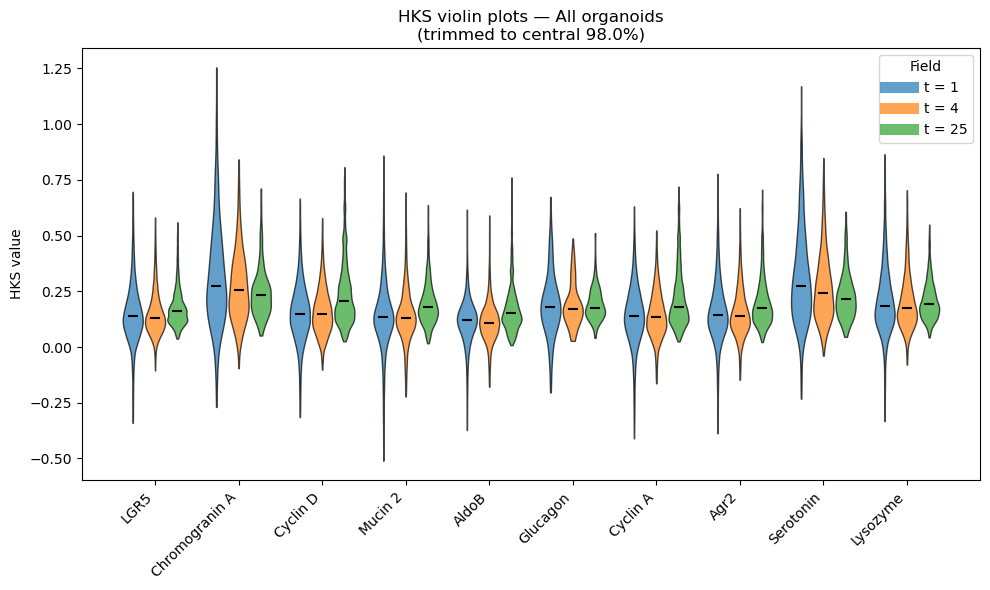

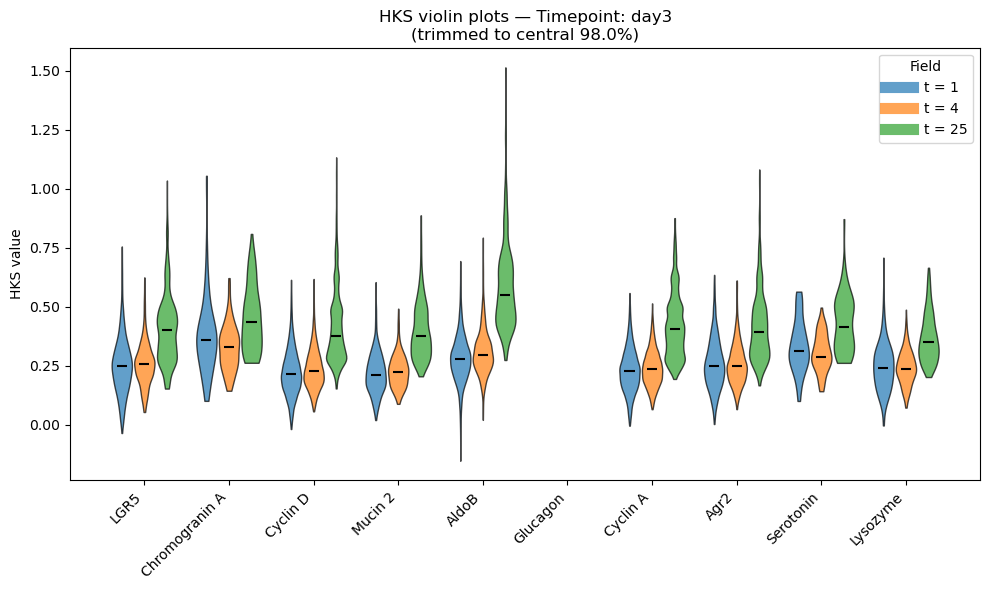

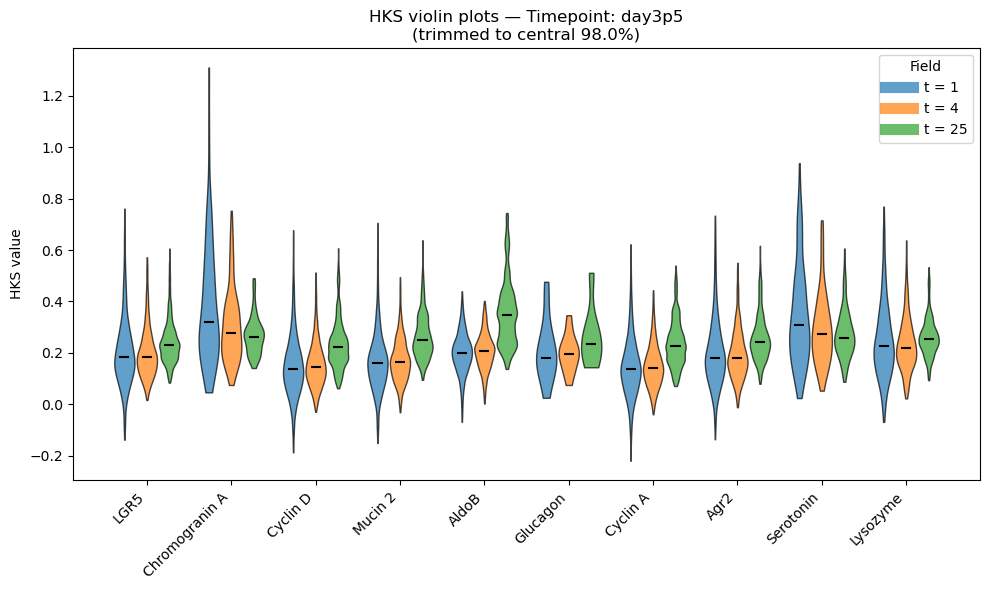

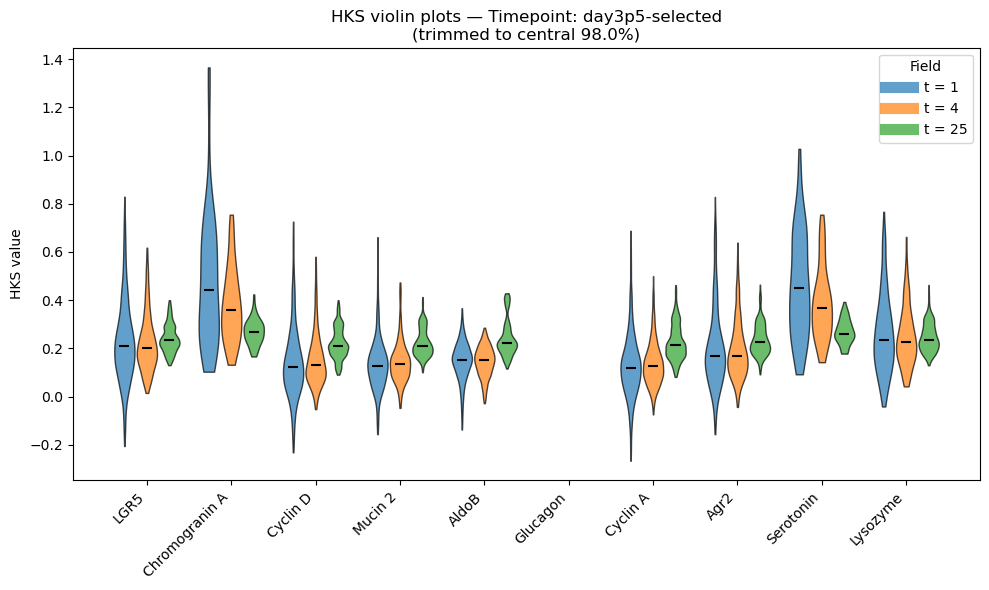

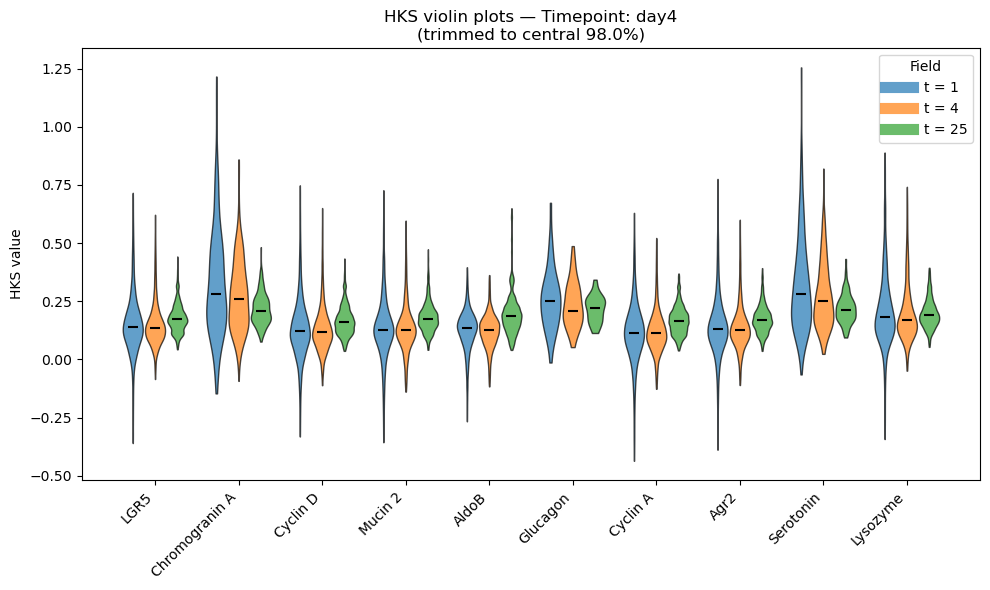

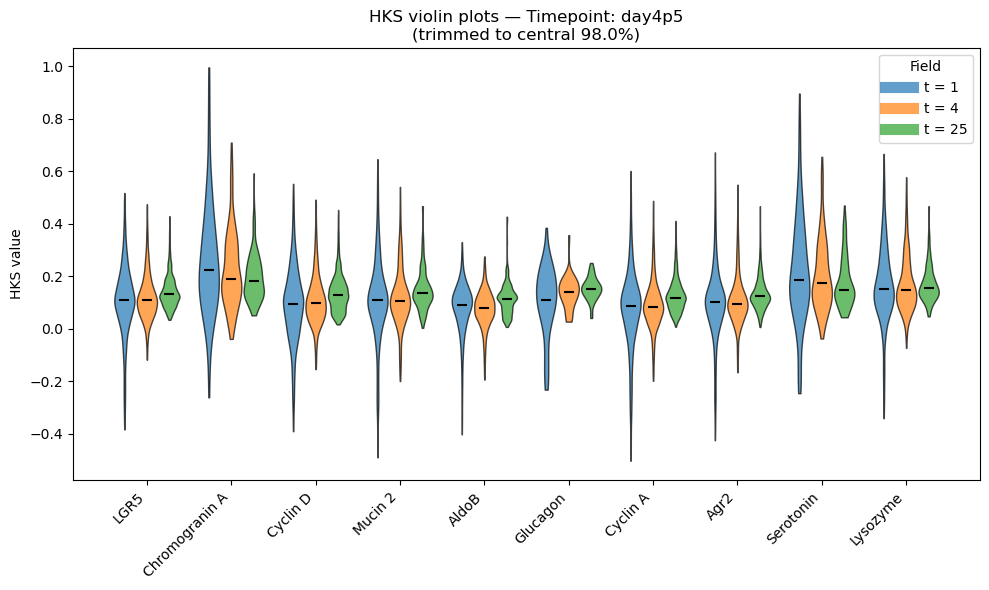

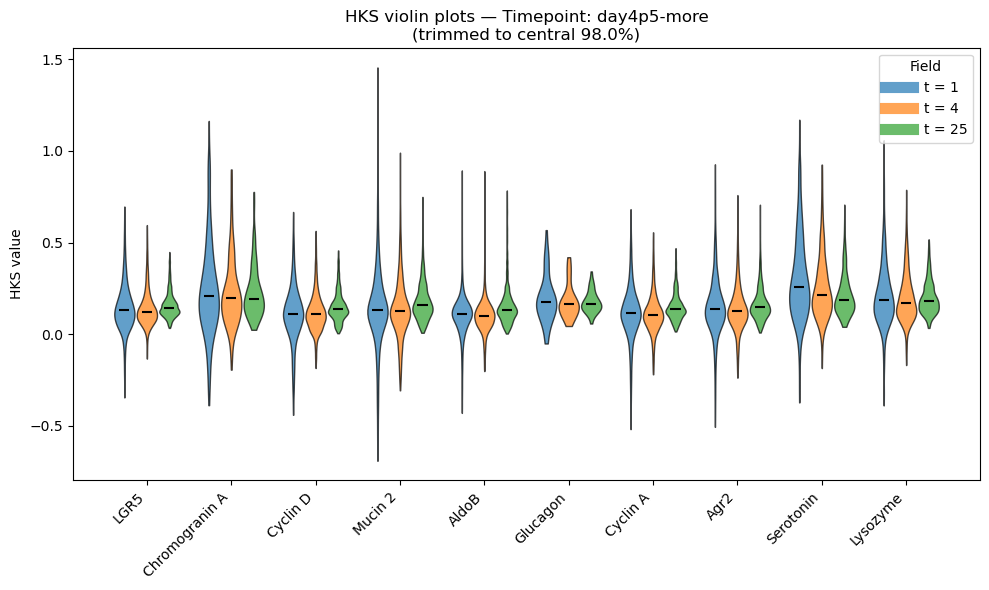

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# --- Labels for the HKS fields ---
field_labels = ["t = 1", "t = 4", "t = 25"]
n_fields = len(field_labels)


# --- Gather HKS values for each marker & timepoint ---
def gather_hks_data(results):
    """
    Return:
        all_data[marker_idx][field_idx] = list of all HKS values across timepoints/organoids
        tp_data[tp][marker_idx][field_idx] = list of HKS values per timepoint
        marker_names = list of marker names
    """
    # Grab marker names from any timepoint
    first_tp = next(iter(results))
    marker_names = results[first_tp]["marker_names"]
    n_markers = len(marker_names)

    # Initialize containers
    all_data = [[[] for _ in range(n_fields)] for _ in range(n_markers)]
    tp_data = {tp: [[[] for _ in range(n_fields)] for _ in range(n_markers)] for tp in results}

    for tp, res in results.items():
        fields_list = res["fields_cell_all"]
        markers_list = res["markers_cell_all"]
        for org_idx in range(len(fields_list)):
            fields_cell = fields_list[org_idx]   # (N_cells, n_fields)
            fields_cell = hks_to_curv_proxy_Y(fields_cell, np.array([1.0, 4.0, 25.0]))
            markers_cell = markers_list[org_idx] # (N_cells, n_markers)

            for m_idx in range(n_markers):
                mask = markers_cell[:, m_idx].astype(bool)
                if not np.any(mask):
                    continue
                vals = fields_cell[mask, :]  # (n_masked_cells, n_fields)
                for f_idx in range(n_fields):
                    these_vals = vals[:, f_idx]
                    # Store globally
                    all_data[m_idx][f_idx].extend(these_vals.tolist())
                    # Store per timepoint
                    tp_data[tp][m_idx][f_idx].extend(these_vals.tolist())

    return all_data, tp_data, marker_names

# --- Get data ---
all_data, tp_data, marker_names = gather_hks_data(results)
n_markers = len(marker_names)

# Helper: Plot violins for a given data structure (marker_idx × field_idx)
def filter_percentiles(data, lower=2.5, upper=97.5):
    """
    Filter data to keep only values between the given percentiles.
    """
    data = np.asarray(data)
    data = data[np.isfinite(data)]
    if data.size == 0:
        return data
    lo = np.percentile(data, lower)
    hi = np.percentile(data, upper)
    return data[(data >= lo) & (data <= hi)]


def plot_violins_for_dataset(dataset, title, lower_q=2.5, upper_q=97.5):
    """
    Plot violin plots for a dataset [marker_idx][field_idx] with optional percentile trimming.
    Handles empty groups gracefully.
    """
    fig, ax = plt.subplots(figsize=(max(10, n_markers * 0.8), 6))

    positions = []
    data_for_plot = []
    valid_pos = []
    colors = ["tab:blue", "tab:orange", "tab:green"]

    # spacing parameters
    group_width = 0.8
    field_spacing = group_width / n_fields
    base_positions = np.arange(n_markers)

    for m_idx, m_name in enumerate(marker_names):
        for f_idx in range(n_fields):
            pos = m_idx - group_width/2 + (f_idx + 0.5) * field_spacing
            raw_vals = dataset[m_idx][f_idx]
            trimmed_vals = filter_percentiles(raw_vals, lower_q, upper_q)

            # ✅ Skip empty groups to avoid violinplot errors
            if trimmed_vals.size == 0:
                continue

            valid_pos.append(pos)
            data_for_plot.append(trimmed_vals)

    if len(data_for_plot) == 0:
        print(f"⚠ No valid data to plot for {title}")
        return

    parts = ax.violinplot(
        data_for_plot,
        positions=valid_pos,
        widths=field_spacing * 0.9,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    # Color violins by field index (based on order in positions)
    for i, pc in enumerate(parts['bodies']):
        # figure out which field this violin corresponds to:
        # (i // n_fields) won't work since we skipped empty; instead compare position offset
        pos = valid_pos[i]
        m_group = int(round(pos))  # marker group center
        offset = pos - m_group + group_width/2
        f_idx = int(offset // field_spacing)
        f_idx = min(max(f_idx, 0), n_fields - 1)

        pc.set_facecolor(colors[f_idx])
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)

    if 'cmedians' in parts:
        parts['cmedians'].set_color('black')

    ax.set_xticks(base_positions)
    ax.set_xticklabels(marker_names, rotation=45, ha='right')
    ax.set_ylabel("HKS value")
    ax.set_title(f"{title}\n(trimmed to central {100 - lower_q - (100 - upper_q)}%)")

    # Custom legend for fields
    handles = [plt.Line2D([0], [0], color=colors[i], lw=8, alpha=0.7) for i in range(n_fields)]
    ax.legend(handles, field_labels, title="Field", loc="upper right")

    plt.tight_layout()
    plt.show()

# All organoids combined, trim to central 95%
plot_violins_for_dataset(all_data, "HKS violin plots — All organoids", lower_q=1.0, upper_q=99.0)

# Per timepoint, same trimming
for tp, tp_dataset in tp_data.items():
    plot_violins_for_dataset(tp_dataset, f"HKS violin plots — Timepoint: {tp}", lower_q=1.0, upper_q=99.0)
